In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import scipy.stats as scp
import statsmodels.api as sm
from numpy import polyfit
from sklearn.preprocessing import LabelEncoder, Normalizer, StandardScaler, MinMaxScaler, OrdinalEncoder

# Membaca Dataset

In [2]:
csl = pd.read_csv('train_csl.csv')
display(csl.head())

,user_age_group,user_id,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,1972,2017-12-22,male,712,15.8,382,Headquarters Business Park,54 kg and under,Night Ride,13.6,34.9,19.24,5103,5103,0,6977
1,25 to 34,239,2015-04-13,male,189,33.2,216,Oghor 2 SailsIsland,105 kg to 114 kg,Night Ride,21.5,43.2,23.47,3926,3926,0,3518
2,25 to 34,405,2018-02-07,male,264,23.7,593,Starbucks to Majid,75 to 84 kg,Evening Ride,26.7,92.9,38.23,5152,5152,0,415
3,25 to 34,318,2018-08-24,male,50,33.4,817,Al Fardoos to shellfish round about,75 to 84 kg,Afternoon Ride,31.4,54.4,65.77,7548,7548,1,1755
4,25 to 34,628,2020-03-06,female,19,21.3,284,Headquarters Business Park,54 kg and under,ثاني تمرين ١٠٠كم,19.9,43.2,96.53,17493,17493,0,7088


- Categorical = user_age_group, gender, smt_name, user_weight_category, act_title
- Numerical = smt_rank, smt_avg_spd, smt_finish_seconds, act_avg_spd, act_max_spd, act_total_km, act_moving_seconds, act_total_seconds
- Date = attempt_date
- Binary = has_hr_data
- Unique identifier = user_id, id

# Info Terkait Dataset

In [3]:
csl.shape

(6292, 17)

- Terdapat 6292 data dan 17 fitur

In [4]:
csl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6292 entries, 0 to 6291
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        6292 non-null   object 
 1   user_id               6292 non-null   int64  
 2   attempt_date          6292 non-null   object 
 3   gender                6292 non-null   object 
 4   smt_rank              6292 non-null   int64  
 5   smt_avg_spd           6292 non-null   float64
 6   smt_finish_seconds    6292 non-null   int64  
 7   smt_name              6292 non-null   object 
 8   user_weight_category  5932 non-null   object 
 9   act_title             6292 non-null   object 
 10  act_avg_spd           6292 non-null   float64
 11  act_max_spd           6292 non-null   float64
 12  act_total_km          6292 non-null   float64
 13  act_moving_seconds    6292 non-null   int64  
 14  act_total_seconds     6292 non-null   int64  
 15  has_hr_data          

- Terlihat data type setiap kolom
- Terlihat jumlah data yang non-null, hanya fitur user_weight_category yang memiliki missing value

In [5]:
csl.describe()

,user_id,smt_rank,smt_avg_spd,smt_finish_seconds,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
count,6292.000000,6292.000000,6292.00000,6292.000000,6292.000000,6292.000000,6292.000000,6.292000e+03,6.292000e+03,6292.000000,6292.000000
mean,782.421964,172.515893,26.80925,531.276224,22.681024,44.757533,42.147134,1.252379e+04,1.252379e+04,0.196440,3947.028608
std,539.051866,173.487689,8.44806,431.974886,5.851547,17.055338,27.010789,2.157781e+05,2.157781e+05,0.397337,2261.820409
min,2.000000,1.000000,0.80000,112.000000,0.000000,8.600000,2.280000,2.640000e+02,2.640000e+02,0.000000,1.000000
25%,335.000000,37.000000,21.30000,266.000000,18.700000,36.700000,23.440000,4.095000e+03,4.095000e+03,0.000000,2004.750000
50%,703.500000,108.000000,26.50000,439.000000,22.100000,42.100000,37.780000,5.781500e+03,5.781500e+03,0.000000,3941.000000
75%,1096.000000,267.000000,32.50000,651.000000,26.400000,48.600000,52.140000,8.098500e+03,8.098500e+03,0.000000,5907.250000
max,2254.000000,805.000000,87.30000,9224.000000,75.200000,690.800000,706.590000,1.167978e+07,1.167978e+07,1.000000,7863.000000


In [6]:
csl['user_id'].duplicated().value_counts()

user_id
True     4193
False    2099
Name: count, dtype: int64

- Tidak ditemukan data duplikat dalam dataset

# EDA

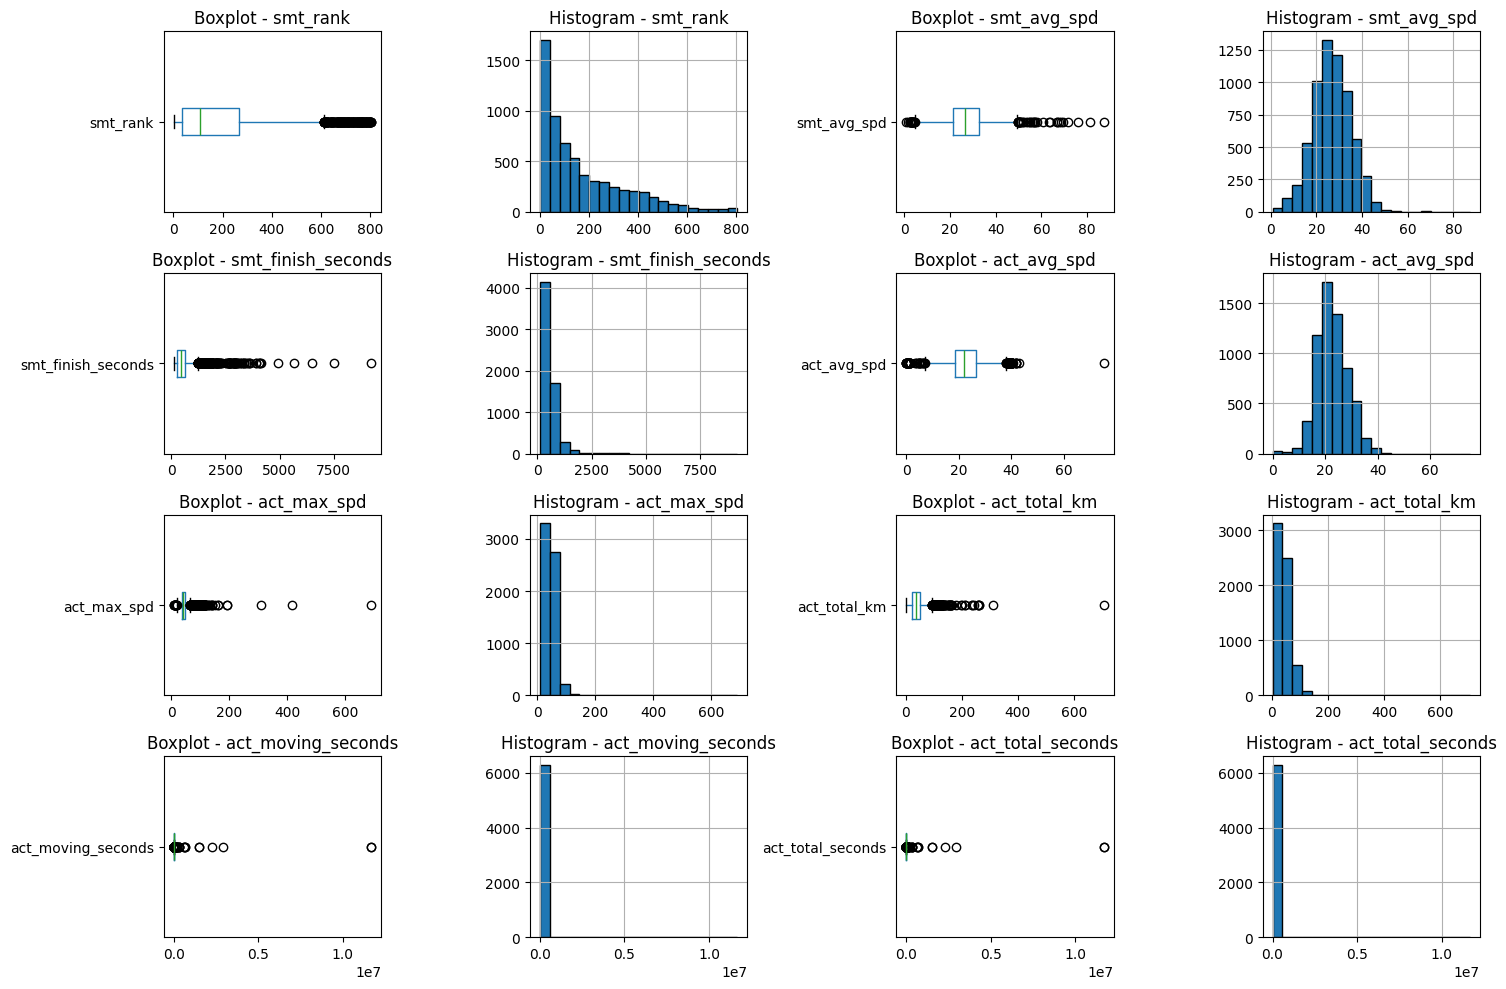

In [7]:
def show_stats(df):
    numeric_cols = df.select_dtypes(include=np.number).columns

    n_features = len(numeric_cols)
    n_cols = 4
    # n_rows = (n_features * 2 + n_cols - 1) // n_cols
    n_rows = (n_features * 2 + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
    axes = axes.ravel()

    for i, col in enumerate(numeric_cols):
        df[[col]].boxplot(ax=axes[2 * i], grid=False, vert=False)
        axes[2 * i].set_title(f'Boxplot - {col}')
        
        df[col].hist(ax=axes[2 * i + 1], bins=20, edgecolor='black')
        axes[2 * i + 1].set_title(f'Histogram - {col}')

    for j in range(2 * n_features, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

show_stats(csl.drop(['user_id', 'id', 'has_hr_data'], axis=1))

- Hampir semua fitur numerik memiliki outlier
- Sebagian memiliki outlier yang cukup ekstrim, seperti smt_finish_seconds, act_avg_spd, act_max_spd, act_total_km, act_moving_seconds, act_total_seconds
- Beberapa fitur merupakan skewed data, seperti smt_rank, smt_finish_seconds, act_max_spd, act_total_km, act_moving_sconds, act_total_seconds

In [8]:
csl_categoric = csl.select_dtypes(include = np.object_)
#pd.set_option('display.max_rows', 60) #change how many rows shows in output, current = 60, if None = no limit

for col in csl_categoric.columns:
    display(csl_categoric[col].value_counts())

user_age_group
25 to 34        2708
35 to 44        1866
45 to 54         667
20 to 24         568
19 and under     297
55 to 64         152
65 to 69          16
75+               15
70 to 74           3
Name: count, dtype: int64

attempt_date
2019-04-27    62
2019-01-26    41
2019-04-19    38
2019-02-22    25
2019-10-11    25
              ..
2014-02-07     1
2019-11-17     1
2014-09-23     1
2016-08-23     1
2015-07-12     1
Name: count, Length: 1457, dtype: int64

gender
male      6039
female     253
Name: count, dtype: int64

smt_name
Headquarters Business Park                    1545
Oghor 2 SailsIsland                           1260
North Corniche                                1056
Starbucks to Majid                             865
King Street side                               592
PRINCE SULTAN - ASSALAM TO FATIMA              361
S.Ubhur Alkurnaysh South Bound with detour     255
Obhur North Short                              201
Al Fardoos to shellfish round about            157
Name: count, dtype: int64

user_weight_category
54 kg and under     1972
75 to 84 kg         1162
65 to 74 kg          842
85 to 95 kg          835
95 kg to 104 kg      425
55 to 64 kg          279
105 kg to 114 kg     241
115 kg and over      176
Name: count, dtype: int64

act_title
Evening Ride                                                  1770
Morning Ride                                                  1467
Night Ride                                                     831
Afternoon Ride                                                 582
Lunch Ride                                                      32
                                                              ... 
Monday Evening Ride person biking  night with stars Jeddah       1
تمرين خفيف لطيف رغم الهواء القوي عكس مو مكتوب في الطقس ،         1
Test ride with my daughter on chiled seat                        1
احلى تمرين مع شباب الاسبيدر                                      1
Night Ridefff                                                    1
Name: count, Length: 1051, dtype: int64

- Terlihat class-class yang ada dan jumlah occurence
- Fitur attempt_date bisa diubah menjadi kolom year, month, dan day
- Mayoritas fitur bisa diencode karena jumlah class yang cukup kecil, seperti user_age_group, gender, smt_name, dan user_weight_category
- Ada fitur karena jumlah class yang terlalu besar, yakni act_title

# EDA Insights

### 1. Apakah umur dan berat badan mempengaruhi performa bersepeda?

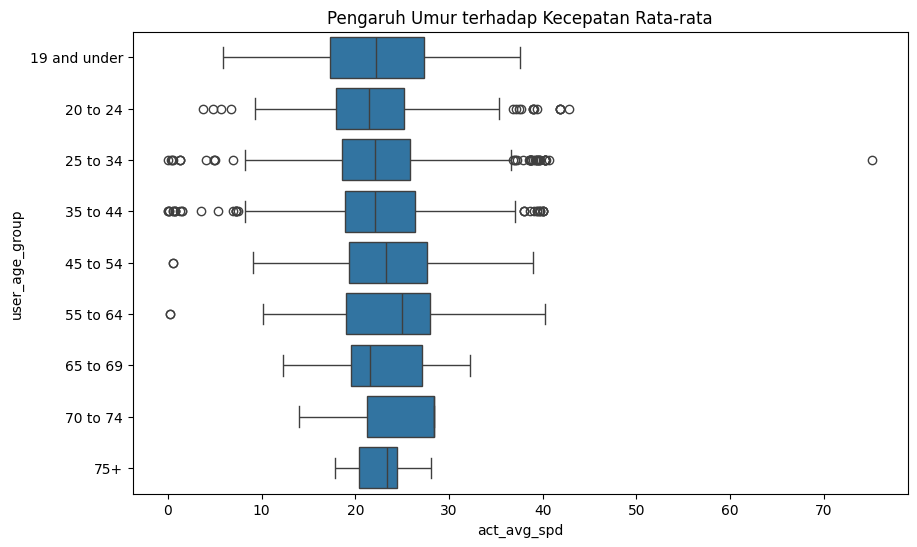

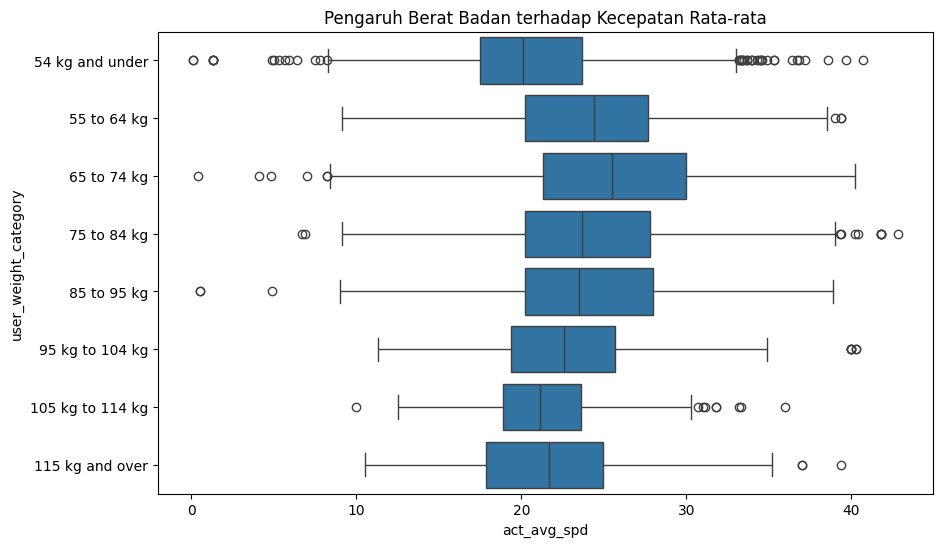

<Axes: >

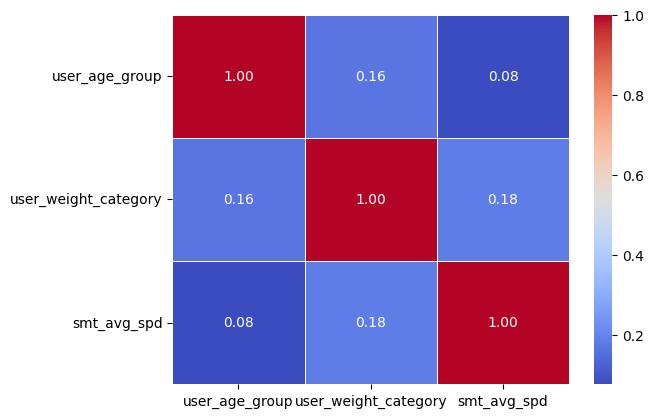

In [9]:
# Menambahkan kolom 'age_group' dan 'weight_category' (asumsikan kolom umur dan berat tersedia sebagai `age` dan `weight`)
# csl['age_group'] = pd.cut(csl['user_age_group'], bins=[0, 20, 30, 40, 50, 60, 100], labels=['<20', '20-30', '30-40', '40-50', '50-60', '>60'])
# csl['weight_category'] = pd.cut(csl['user_weight_category'], bins=[0, 60, 80, 100, 150], labels=['light', 'medium', 'heavy', 'very_heavy'])

# Visualisasi hubungan antara kelompok umur dan kecepatan rata2
csl_sorted_age = csl.sort_values(by='user_age_group')
plt.figure(figsize=(10, 6))
sns.boxplot(x='act_avg_spd', y='user_age_group', data=csl_sorted_age)
plt.title('Pengaruh Umur terhadap Kecepatan Rata-rata')
plt.show()

# Visualisasi hubungan antara kelompok berat badan dan kecepatan rata2
weight_order = [
    '54 kg and under',
    '55 to 64 kg',
    '65 to 74 kg',
    '75 to 84 kg',
    '85 to 95 kg',
    '95 kg to 104 kg',
    '105 kg to 114 kg',
    '115 kg and over'
]
csl['user_weight_category'] = pd.Categorical(csl['user_weight_category'], categories=weight_order, ordered=True)
csl_sorted_weight = csl.sort_values(by='user_weight_category')
plt.figure(figsize=(10, 6))
sns.boxplot(x='act_avg_spd', y='user_weight_category', data=csl_sorted_weight)
plt.title('Pengaruh Berat Badan terhadap Kecepatan Rata-rata')
plt.show()

# Visualisasi korelasi spearman
age_group_mapping = {
    "19 and under"    :1,
    "20 to 24"        :2,
    "25 to 34"        :3,
    "35 to 44"        :4,
    "45 to 54"        :5,
    "55 to 64"        :6,
    "65 to 69"        :7,
    "70 to 74"        :8,
    "75+"             :9
}

weight_group_mapping = {
    "54 kg and under"    :1,
    "55 to 64 kg"        :2,
    "65 to 74 kg"        :3,
    "75 to 84 kg"        :4,
    "85 to 95 kg"        :5,
    "95 kg to 104 kg"    :6,
    "105 kg to 114 kg"   :7,
    "115 kg and over"    :8
}

temp = csl.copy()
temp.user_age_group = temp.user_age_group.map(age_group_mapping)
temp.user_weight_category = temp.user_weight_category.map(weight_group_mapping)
temp = temp[['user_age_group', 'user_weight_category', 'smt_avg_spd']]
sns.heatmap(temp.corr(method="spearman"),annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")

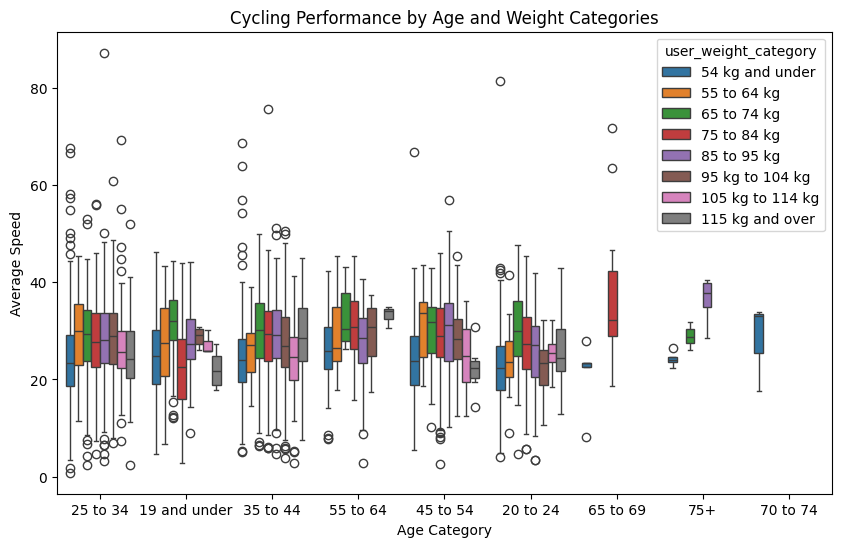

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=csl, x='user_age_group', y='smt_avg_spd', hue='user_weight_category')
plt.title('Cycling Performance by Age and Weight Categories')
plt.ylabel('Average Speed')
plt.xlabel('Age Category')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_15820\2269897121.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = csl.pivot_table(values='smt_avg_spd', index='user_age_group', columns='user_weight_category', aggfunc='median')


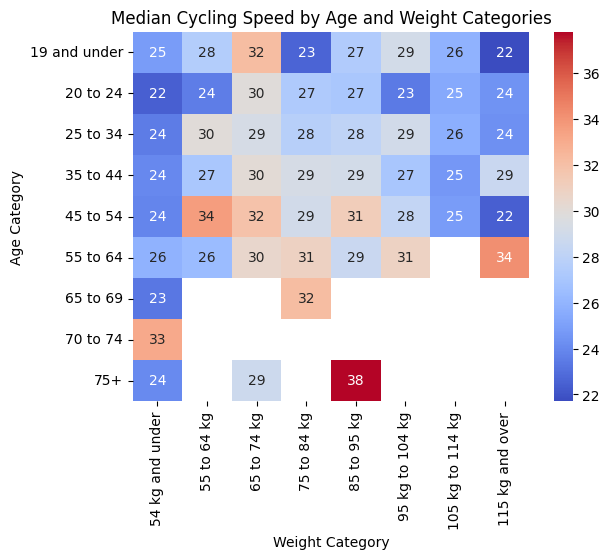

In [11]:
pivot_table = csl.pivot_table(values='smt_avg_spd', index='user_age_group', columns='user_weight_category', aggfunc='median')
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title('Median Cycling Speed by Age and Weight Categories')
plt.ylabel('Age Category')
plt.xlabel('Weight Category')
plt.show()

Insight:

Korelasi antara umur dan berat badan dengan kecepatan rata-rata pada suatu segmen sangat kecil

### 2. Apakah terdapat perbedaan performa bersepeda antara laki-laki dan perempuan pada segmen yang sama?

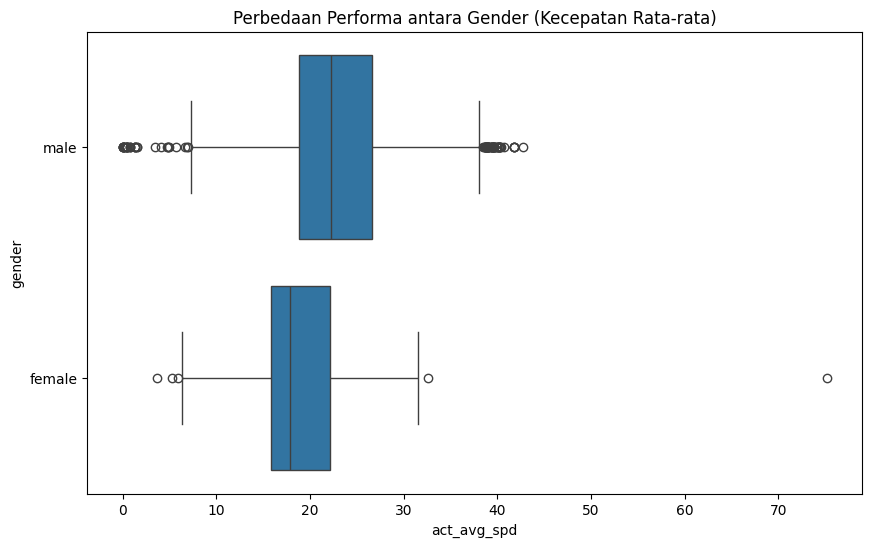

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='act_avg_spd', y='gender', data=csl)
plt.title('Perbedaan Performa antara Gender (Kecepatan Rata-rata)')
plt.show()

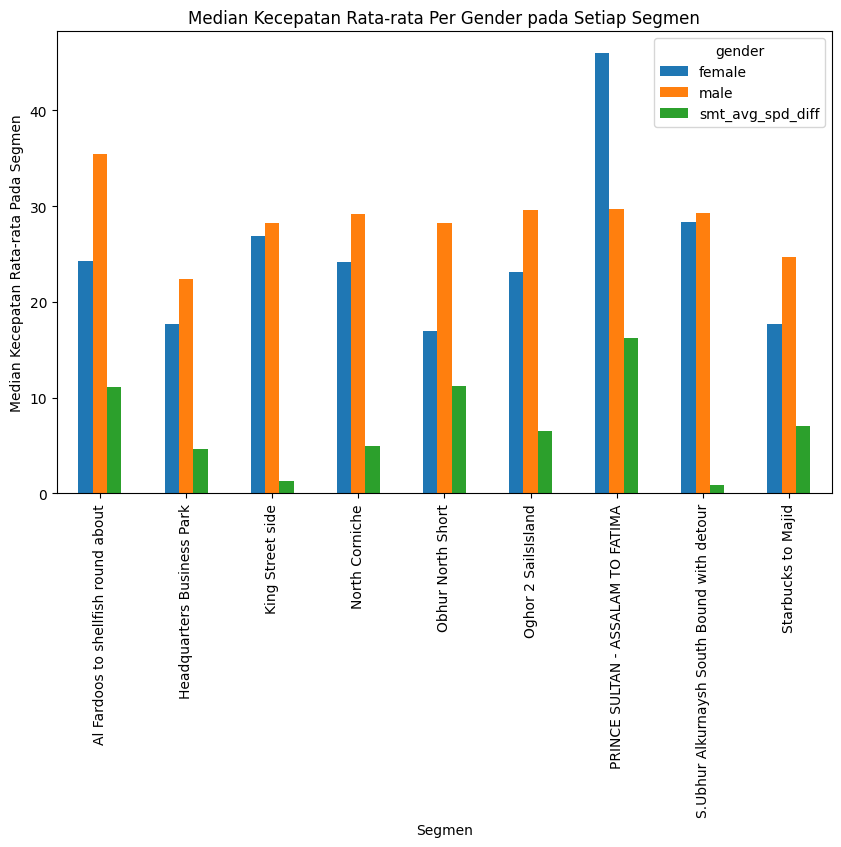

In [13]:
temp = csl.groupby(['smt_name', 'gender'])['smt_avg_spd'].median().unstack()

temp['smt_avg_spd_diff'] = abs(temp['male'] - temp['female'])
temp.plot(kind='bar', figsize=(10, 6))
plt.title('Median Kecepatan Rata-rata Per Gender pada Setiap Segmen')
plt.xlabel('Segmen')
plt.ylabel('Median Kecepatan Rata-rata Pada Segmen')
plt.show()


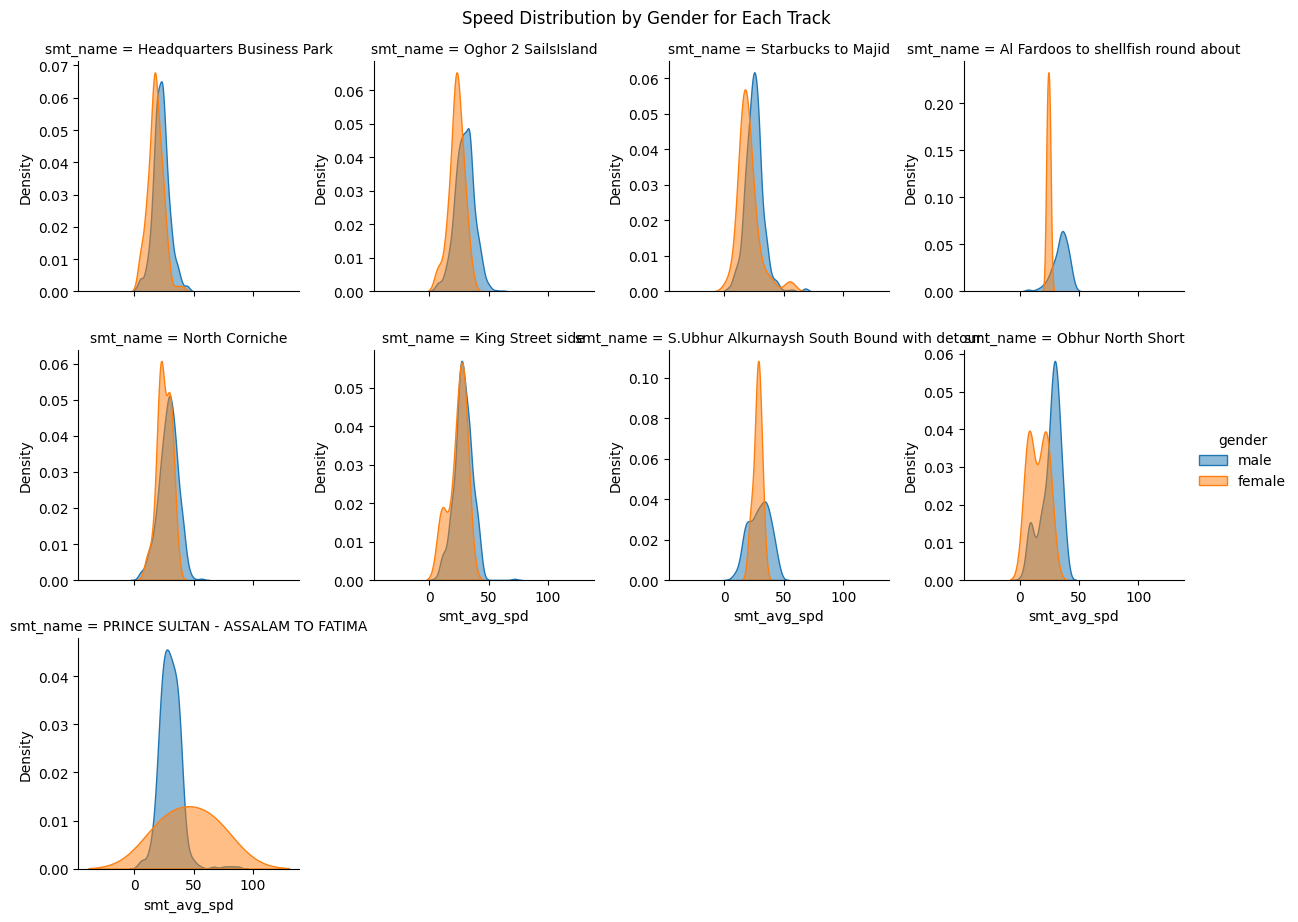

In [14]:
g = sns.FacetGrid(csl, col='smt_name', hue='gender', col_wrap=4, sharey=False)
g.map(sns.kdeplot, 'smt_avg_spd', fill=True, alpha=0.5)
g.add_legend()
g.fig.suptitle('Speed Distribution by Gender for Each Track', y=1.02)
plt.show()

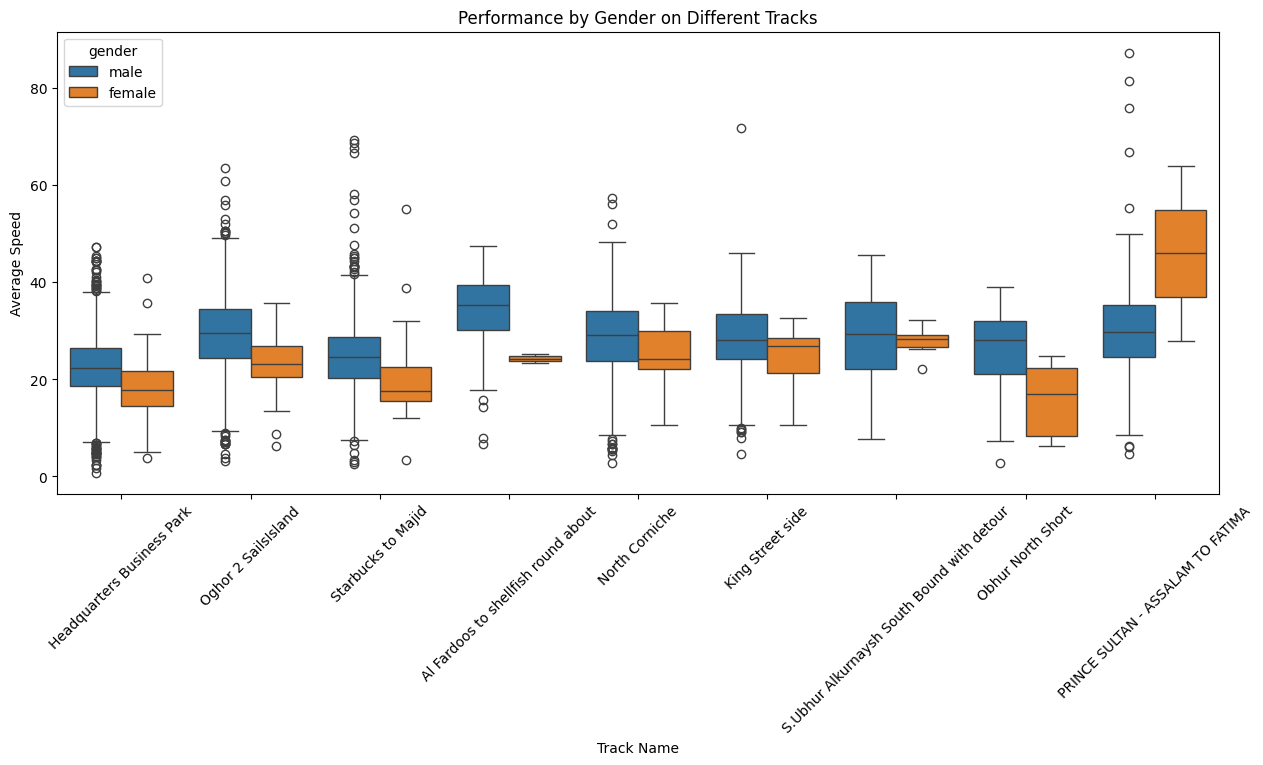

In [15]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=csl, x='smt_name', y='smt_avg_spd', hue='gender')
plt.title('Performance by Gender on Different Tracks')
plt.ylabel('Average Speed')
plt.xlabel('Track Name')
plt.xticks(rotation=45)
plt.show()

Insight:

Secara umum, laki-laki sedikit lebih cepat daripada perempuan, kecuali pada segmen "PRINCE SULTAN - ASSALAM TO FATIMA"

### 3. Bagaimana karakteristik performa dan fisik top 10% pemenang?

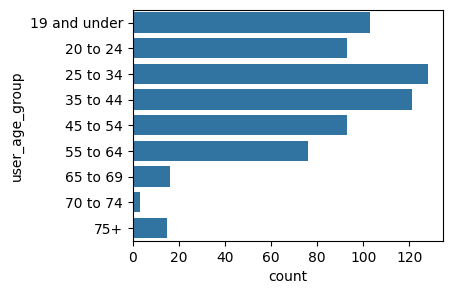

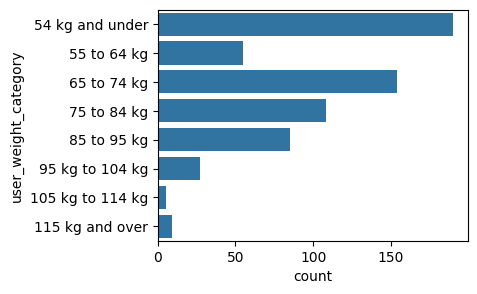

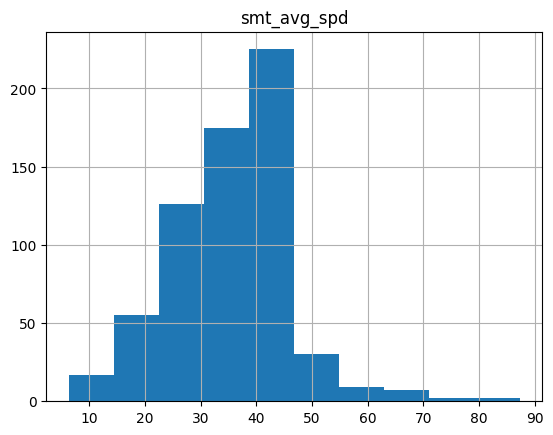

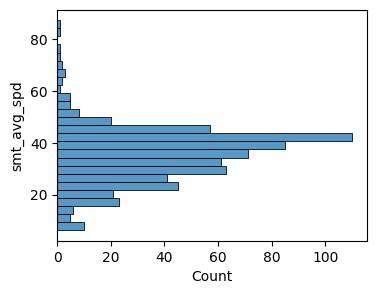

In [ ]:
# Menghitung batas top 10% berdasarkan rank dalam segmen
top_10_percent_threshold = csl['smt_rank'].quantile(0.1)
top_10_percent = csl[csl['smt_rank'] <= top_10_percent_threshold]
top_10_percent = top_10_percent[['user_age_group', 'user_weight_category', 'smt_avg_spd']]

# Visualisasi karakteristik fisik dan performa
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='user_age_group', y='smt_avg_spd', data=top_10_percent)
# plt.title('Karakteristik Umur di Top 10% Pesepeda Tercepat')
# plt.show()

for col in top_10_percent.select_dtypes(include = [np.object_, "category"]).columns:
    top_10_percent.sort_values(col, inplace=True)
    plt.figure(figsize=(4,3))
    sns.countplot(y=top_10_percent[col])
    plt.show()

plt.figure(figsize=(4,3))
sns.histplot(y=top_10_percent['smt_avg_spd'])
plt.show()

Insight:
- Umumnya lebih muda, dimana paling banyak di sekitaran mid 20 ke mid 40
- Umumnya memiliki bb yang lebih rendah, dimana paling banyak memiliki bb dibawah 55kg
- Memiliki kecepatan rata-rata segmen yang cukup cepat, sekitar 40km/jam

### 4. Segmen apa yang memiliki leaderboard perempuan dan laki-laki dengan performa paling unggul?

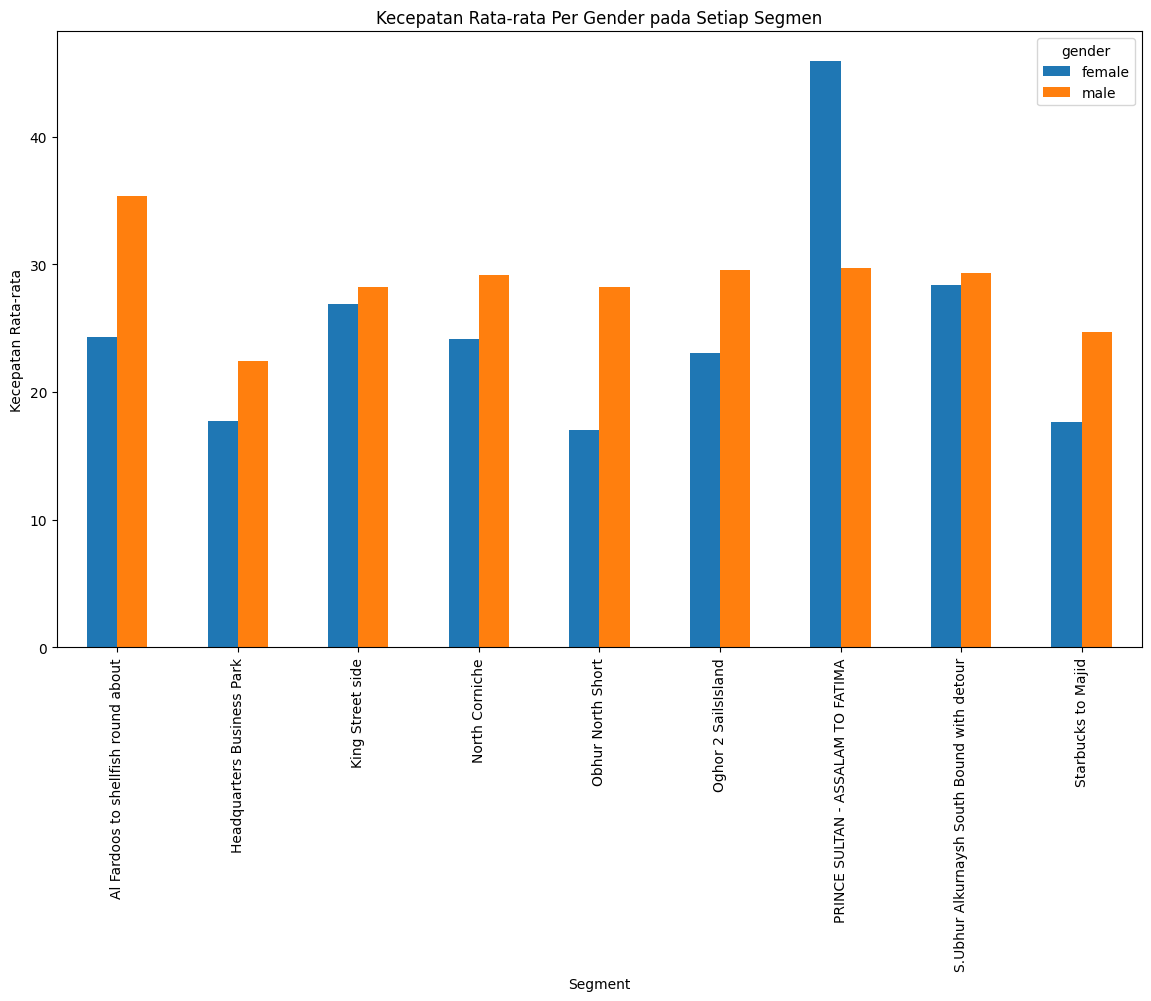

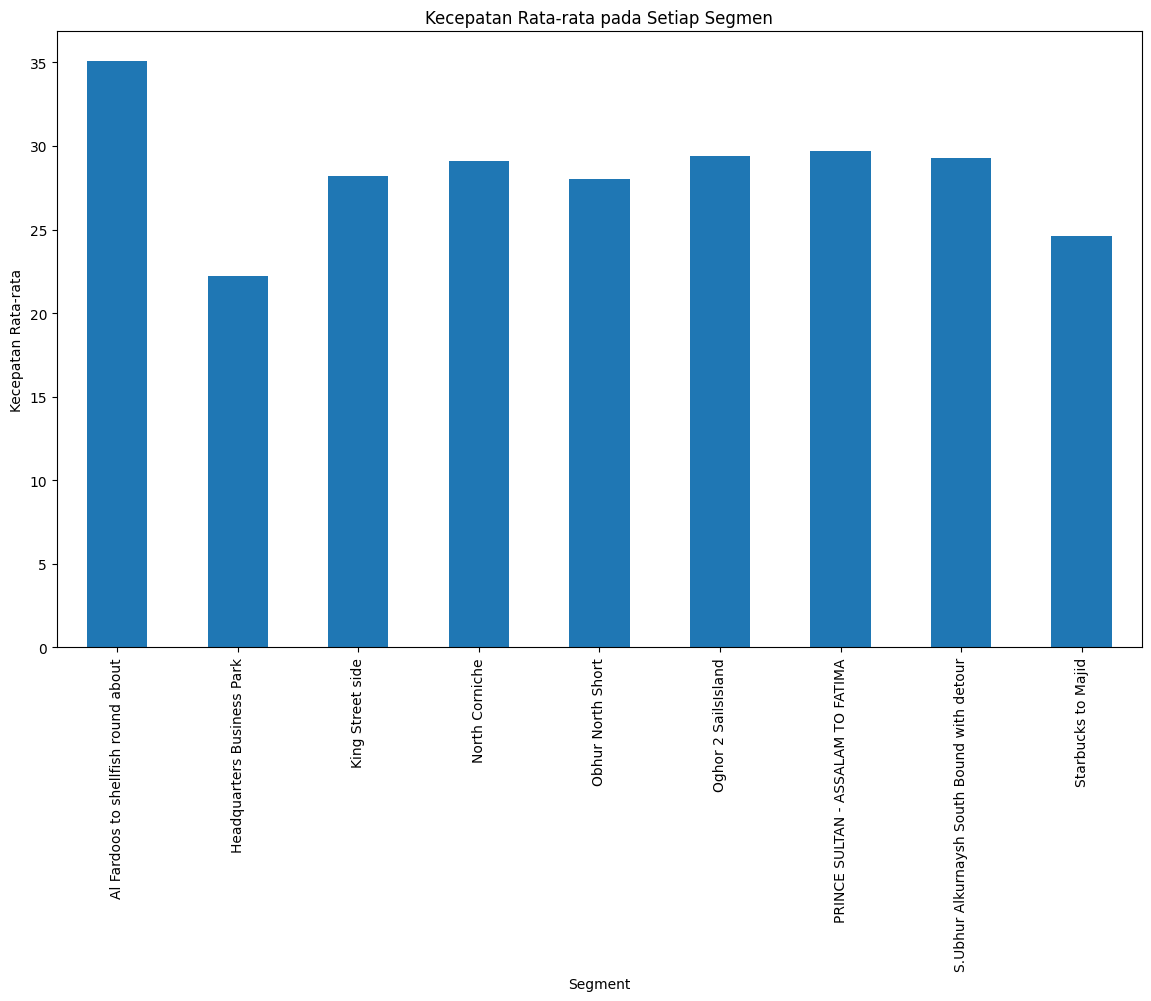

In [22]:
# Menghitung kecepatan rata-rata per segmen untuk laki-laki dan perempuan
top_segments = csl.groupby(['smt_name', 'gender'])['smt_avg_spd'].median().unstack()

# Visualisasi segmen dengan kecepatan tertinggi
top_segments.plot(kind='bar', figsize=(14, 8))
plt.title('Kecepatan Rata-rata Per Gender pada Setiap Segmen')
plt.xlabel('Segment')
plt.ylabel('Kecepatan Rata-rata')
plt.show()

# Menghitung kecepatan rata-rata per segmen untuk laki-laki dan perempuan
top_segments = csl.groupby(['smt_name'])['smt_avg_spd'].median()#.unstack()

# Visualisasi segmen dengan kecepatan tertinggi
top_segments.plot(kind='bar', figsize=(14, 8))
plt.title('Kecepatan Rata-rata pada Setiap Segmen')
plt.xlabel('Segment')
plt.ylabel('Kecepatan Rata-rata')
plt.show()

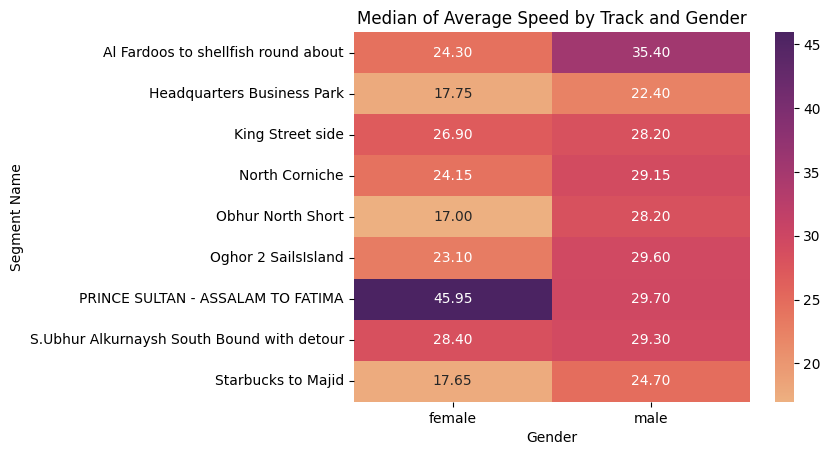

In [33]:
pivot_table = csl.pivot_table(values='smt_avg_spd', index='smt_name', columns='gender', aggfunc='median')
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='flare', cbar=True)
plt.title('Median of Average Speed by Track and Gender')
plt.ylabel('Segment Name')
plt.xlabel('Gender')
plt.show()

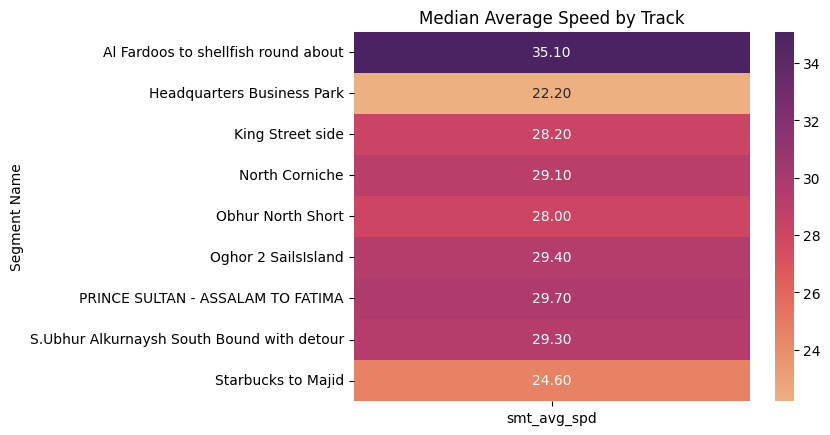

In [34]:
pivot_table = csl.pivot_table(values='smt_avg_spd', index='smt_name', aggfunc='median')
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='flare', cbar=True)
plt.title('Median Average Speed by Track')
plt.ylabel('Segment Name')
plt.show()

Insight:
- Laki-laki paling unggul ada pada segmen "Al Fardoos to shellfish round about"
- Perempuan paling unggul ada pada segmen "PRINCE SULTAN - ASSALAM TO FATIMA"
- Secara umum, segmen yang memiliki performa rata-rata paling unggul ada di segmen "Al Fardoos to shellfish round about"

### 5. Apakah terdapat perbedaan total jarak aktivitas antara gender?

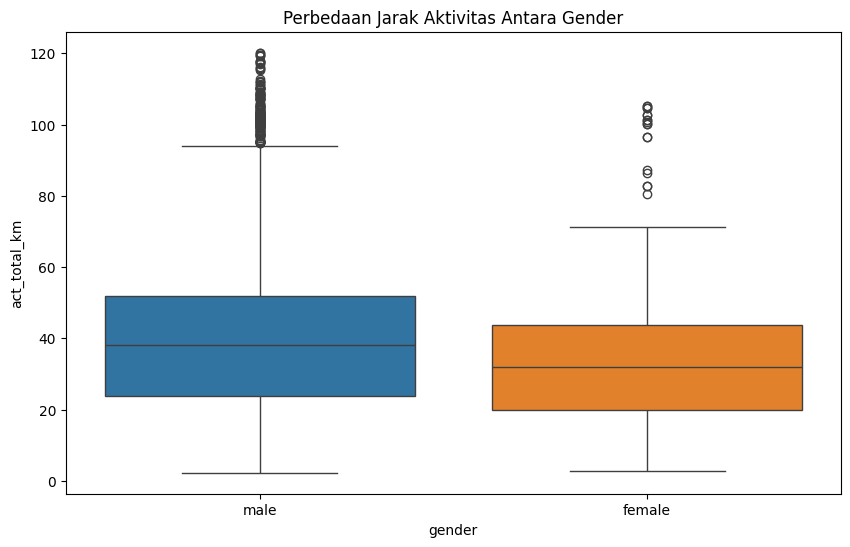

In [40]:
# # Menghitung kecepatan rata-rata per segmen untuk laki-laki dan perempuan
# temp = csl.groupby(['gender'])['act_total_km'].mean()

# # Visualisasi segmen dengan kecepatan tertinggi
# temp.plot(kind='box', figsize=(14, 8))
# plt.title('Rata-rata Jarak Aktivitas Per Gender')
# plt.xlabel('Gender')
# plt.ylabel('Avg Jarak Aktivitas')
# plt.show()
def remove(df, low_lim, high_lim):
    col = df.select_dtypes(include=np.number).columns

    lower_limit = df[col].quantile(low_lim)
    upper_limit = df[col].quantile(high_lim)

    df_no_outlier = df[(df[col] >= lower_limit).all(axis=1) & (df[col] <= upper_limit).all(axis=1)]

    return df_no_outlier

csl_no_crazy_people = remove(csl, 0, 0.99)

plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='act_total_km', data=csl_no_crazy_people, hue = 'gender')
plt.title('Perbedaan Jarak Aktivitas Antara Gender')
plt.show()

Insight:

- Median act_total_km untuk male lebih tinggi dibandingkan dengan female, menunjukkan bahwa rata-rata pria cenderung menempuh jarak aktivitas yang lebih jauh dibandingkan wanita.

- Male memiliki rentang interkuartil (IQR, yaitu Q3-Q1) yang lebih besar daripada female, menunjukkan bahwa jarak aktivitas pria lebih bervariasi.

- Pada kelompok male, terdapat lebih banyak outlier dibandingkan female, terutama di sisi atas (jarak yang sangat jauh). Ini menunjukkan beberapa pria menempuh jarak yang jauh lebih ekstrem.

### 6. Apakah karakteristik gender dan umur seluruh pengguna?

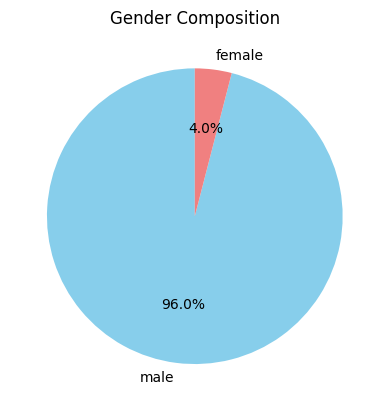

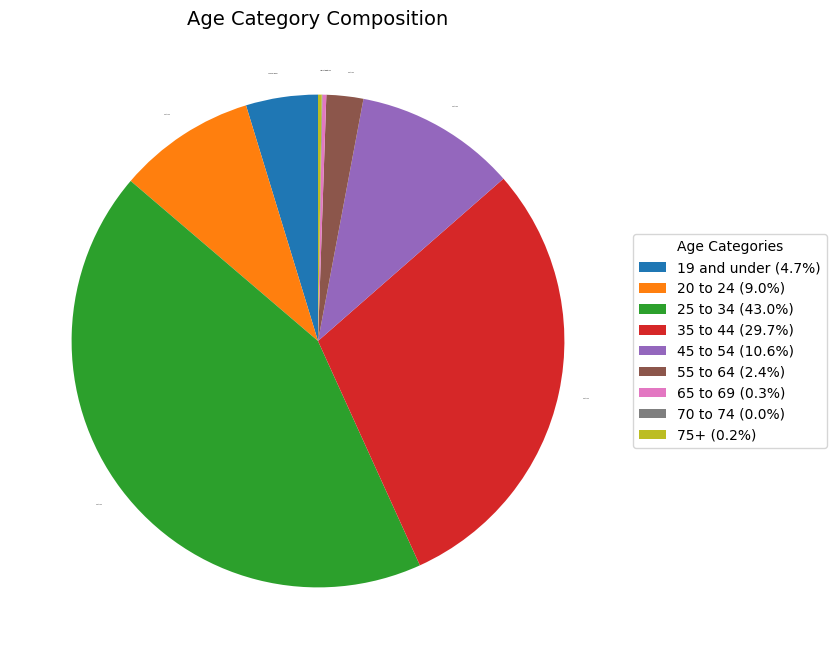

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='has_hr_data', y='smt_avg_spd', data=csl)
# plt.title('Perbedaan Performa antara Pengguna dengan dan tanpa Data Heart Rate')
# plt.show()

gender_count = csl['gender'].value_counts()
plt.pie(gender_count, labels=gender_count.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Gender Composition')
plt.show()

# Sort by the age group order (from youngest to oldest) explicitly
age_count = csl['user_age_group'].value_counts()
age_count = age_count.reindex(sorted(age_count.index))

# Compute percentages for the legend
percentages = (age_count / age_count.sum() * 100).round(1)

# Create the pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    age_count, 
    labels=age_count.index, 
    autopct=' ', 
    startangle=90, 
    textprops={'fontsize': 0}
)

# Add a legend
legend_labels = [f"{label} ({percent}%)" for label, percent in zip(age_count.index, percentages)]
plt.legend(wedges, legend_labels, title="Age Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Add a title
plt.title('Age Composition', fontsize=14)

plt.show()

Insight:

Proporsi gender terbesar adalah laki-laki dengan 96%.

Proporsi umur terbesar adalah umur 25 sampai 44 tahun.